## Imports

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
import os
import datetime
import math
import scipy

from openradar.mmwave import dsp
from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.doppler_processing import doppler_processing
from openradar.mmwave.dsp.utils import Window

## Data path and cofigs

In [15]:
DATA_PATH=r"../data\Rock_vibration\adc_data_2026-06-12_11-55-04_rock_layer_staticto100.npy"
DATA_PATH=DATA_PATH.replace("\\","/")
FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]

save_dir = f"../Simulations/Radar/{FILENAME}"
os.makedirs(save_dir, exist_ok=True)

FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]
print(FILENAME)
numFrames = 300
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

rock_layer_staticto100


## Data loading

In [77]:
adc_data = np.load(DATA_PATH)
print("Raw data shape : " , adc_data.shape)

adc_data = np.apply_along_axis(DCA1000.organize, 1, adc_data,num_chirps=numChirpsPerFrame,num_rx=numRxAntennas, num_samples=numADCSamples)
print("Reshaped data shape: ", adc_data.shape)

Raw data shape :  (300, 1118208)
Reshaped data shape:  (300, 546, 4, 256)


## Range FFT

In [83]:
radar_cubes = np.array([range_processing(frame) for frame in adc_data])

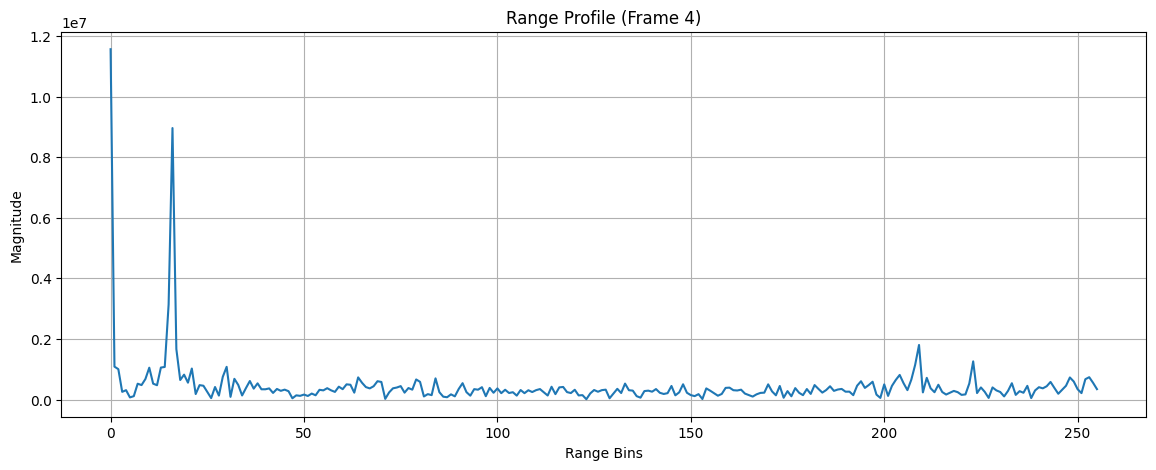

In [84]:
magnitude_data = np.abs(radar_cubes[50][0, 0, :])
# magnitude_db = 20 * np.log10(magnitude_data + 1e-10)
bins = np.arange(256)

plt.figure(figsize=(14, 5))
plt.plot(bins, magnitude_data)
plt.title("Range Profile (Frame 4)")
plt.xlabel("Range Bins")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

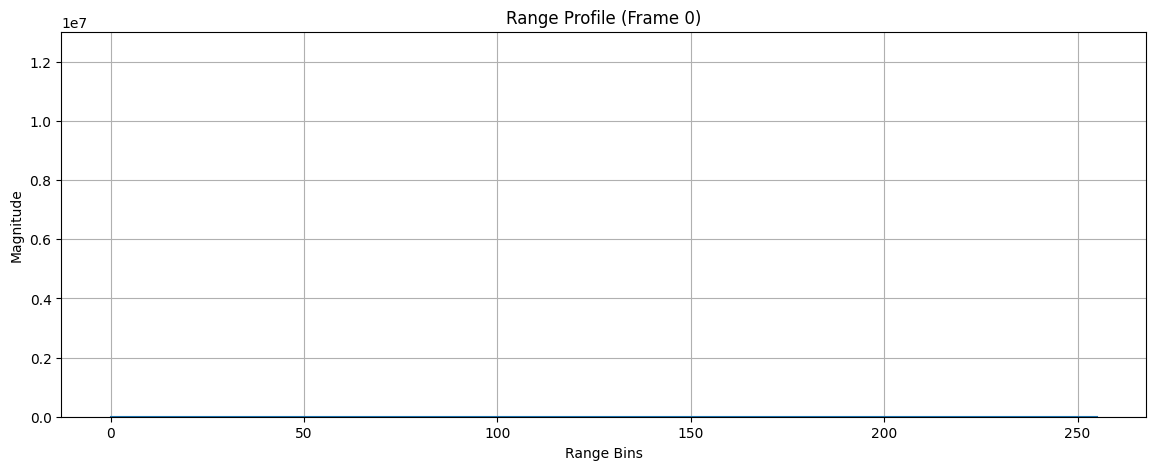

In [85]:
fig, ax = plt.subplots(figsize=(14, 5))
bins = np.arange(256)
global_max = np.max(np.abs(radar_cubes[:, 0, 0, :]))

magnitude_data_initial = np.abs(radar_cubes[0][0, 0, :])
line, = ax.plot(bins, magnitude_data_initial)

ax.set_xlabel("Range Bins")
ax.set_ylabel("Magnitude")
ax.grid(True)

ax.set_ylim(0, global_max * 1.1 + 1e-6)
def update(frame):
    magnitude_data = np.abs(radar_cubes[frame][0, 0, :])
    line.set_ydata(magnitude_data)
    ax.set_title(f"Range Profile (Frame {frame})")
    return [line]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(radar_cubes), 
    interval=50, 
    blit=False
)

target_folder = os.path.join(save_dir, "FFTs")
os.makedirs(target_folder, exist_ok=True)
ani.save(f"{save_dir}/FFTs/Range.gif", writer="pillow")

## Doppler FFT

In [86]:
det_matrices = []
aoa_inputs = []

for cube in radar_cubes:
    det_matrix, aoa_input = doppler_processing(
        cube,
        num_tx_antennas=3, 
        clutter_removal_enabled=False,
        interleaved=True, 
        window_type_2d=Window.HANNING,
        accumulate=True     
    )
    det_matrices.append(det_matrix)
    aoa_inputs.append(aoa_input)

det_matrices = np.array(det_matrices)
aoa_inputs = np.array(aoa_inputs)

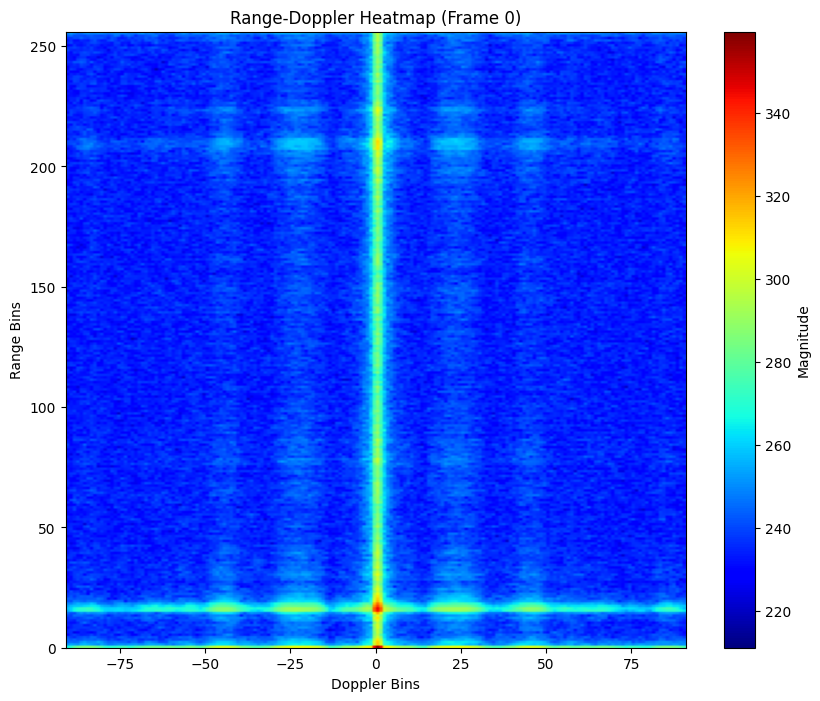

In [87]:
rd_map = det_matrices[50]
rd_map_shifted = np.fft.fftshift(rd_map, axes=1)

global_vmin = np.min(det_matrices)
global_vmax = np.max(det_matrices)

fig, ax = plt.subplots(figsize=(10, 8))
initial_map = np.fft.fftshift(det_matrices[0], axes=1)

num_range_bins, num_doppler_bins = rd_map_shifted.shape
extent = [-num_doppler_bins // 2, num_doppler_bins // 2, 0, num_range_bins]

im = ax.imshow(
    initial_map, 
    aspect='auto', 
    origin='lower', 
    cmap='jet', 
    extent=extent,
    vmin=global_vmin, 
    vmax=global_vmax
)

ax.set_xlabel("Doppler Bins")
ax.set_ylabel("Range Bins")
cbar = fig.colorbar(im, label="Magnitude")

def update(frame):
    rd_map_shifted = np.fft.fftshift(det_matrices[frame], axes=1)
    im.set_array(rd_map_shifted)
    ax.set_title(f"Range-Doppler Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(det_matrices), 
    interval=50, 
    blit=False  
)

ani.save(f"{save_dir}/FFTs/Doppler.gif", writer="pillow")

## Phase Difference

In [8]:
def iterative_range_bins_detection(rangeResult, min_bin=10, max_bin=None):
    rangeResult = np.transpose(np.stack([rangeResult[0::3], rangeResult[1::3], rangeResult[2::3]], axis=1),axes=(1,2,0,3))
    range_result_absnormal_split=[]
    
    for i in range(numTxAntennas):
        for j in range(numRxAntennas):
            r_r=np.abs(rangeResult[i][j])
            
            r_r[:, :min_bin] = 0 # Zero out everything before min_bin
            if max_bin is not None:
                r_r[:, max_bin:] = 0 # Zero out everything after max_bin
            # ----------------------------------------------
                
            min_val = np.min(r_r)
            max_val = np.max(r_r)
            
            # Prevent division by zero if the array is completely empty
            if max_val == min_val: 
                r_r_normalise = np.zeros_like(r_r)
            else:
                r_r_normalise = (r_r - min_val) / (max_val - min_val) * (1000 - 0) + 0
                
            range_result_absnormal_split.append(r_r_normalise)
    
    range_abs_combined_nparray=np.zeros((numLoopsPerFrame,numADCSamples))
    for ele in range_result_absnormal_split:
        range_abs_combined_nparray+=ele
    range_abs_combined_nparray/=(numTxAntennas*numRxAntennas)
    
    range_abs_combined_nparray_collapsed=np.sum(range_abs_combined_nparray,axis=0)/numLoopsPerFrame
    peaks_min_intensity_threshold = np.argsort(range_abs_combined_nparray_collapsed)[::-1][:max_bin-min_bin]
    max_range_index=np.argmax(range_abs_combined_nparray_collapsed)
    
    return max_range_index, peaks_min_intensity_threshold, rangeResult

def get_phase(r, i):
    return np.angle(complex(r, i))

def phase_unwrapping(phase_len,phase_cur_frame):
    i=1
    new_signal_phase = phase_cur_frame
    for k,ele in enumerate(new_signal_phase):
        if k==len(new_signal_phase)-1:
            continue
        if new_signal_phase[k+1] - new_signal_phase[k] > 1.5*np.pi:
            new_signal_phase[k+1:] = new_signal_phase[k+1:] - 2*np.pi*np.ones(len(new_signal_phase[k+1:]))
    return np.array(new_signal_phase)

def solve_equation(phase_cur_frame):
    phase_diff=[]
    for soham in range (1,len(phase_cur_frame)):
        phase_diff.append(phase_cur_frame[soham]-phase_cur_frame[soham-1])
    L=100
    r0=20
    roots_of_frame=[]
    for i,val in enumerate(phase_diff):
        c=(phase_diff[i]*0.001/3.14)/(3*(Tp+Tc))
        t=3*(i+1)*(Tp+Tc)
        c1=t*t
        c2=-2*L*t
        c3=L*L-c*c*t*t
        c4=2*L*c*c*t
        c5=-r0*r0*c*c
        coefficients=[c1, c2, c3, c4, c5]
        root=min(np.abs(np.roots(coefficients)))
        roots_of_frame.append(root)
    median_root=np.median(roots_of_frame)
    final_roots=[]
    for root in roots_of_frame:
        if root >0.9*median_root and root<1.1*median_root:
            final_roots.append(root)
    return np.mean(final_roots)

def get_velocity_antennawise(range_FFT_,peak):
    phase_per_antenna=[]
    vel_peak=[]
    for k in range(0,numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase=get_phase(r,i)
        phase_per_antenna.append(phase)
    phase_cur_frame=phase_unwrapping(len(phase_per_antenna),phase_per_antenna)
    cur_vel=solve_equation(phase_cur_frame)
    return cur_vel

def get_phase_antennawise(range_FFT_, peak):
    phase_per_antenna = []
    for k in range(numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase_per_antenna.append(get_phase(r, i))
    
    phase_cur_frame = np.unwrap(phase_per_antenna)
    phase_cur_frame -= np.mean(phase_cur_frame)   # <-- add this
    return phase_cur_frame

def get_averaged_phase(rangeResult, target_bin):
    best_snr = -np.inf
    best_phase = None
    for tx in range(numTxAntennas):
        for rx in range(numRxAntennas):
            signal = rangeResult[tx][rx][:, target_bin]
            snr = np.mean(np.abs(signal)**2)
            if snr > best_snr:
                best_snr = snr
                best_phase = np.unwrap(np.angle(signal))
    best_phase -= np.mean(best_phase)
    return best_phase

In [94]:
def plot_continuous_phase_diff(all_phase_diffs, target_bin, start_frame, num_frames, save_dir):
    fig, ax = plt.subplots(figsize=(15, 4))
    
    ax.plot(all_phase_diffs, color='red', marker='.', markersize=0.5, linestyle='-', linewidth=0.3, alpha=0.8)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f"Continuous Phase Difference - Range Bin: {target_bin}\n(Frames {start_frame} to {start_frame + num_frames})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Cumulative Chirp Index (Time)")
    ax.set_ylabel("Phase Diff (Rad)")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    fig.tight_layout()
    
    target_folder = os.path.join(save_dir, "Phase_diff")
    os.makedirs(target_folder, exist_ok=True)
    save_path = f"{save_dir}/Phase_diff/frames{start_frame}_to_{start_frame+num_frames}_bin{target_bin}_continuous.png"
    fig.savefig(save_path, dpi=300)
    plt.close(fig)
    print(f"Saved continuous plot for bin {target_bin} at {save_path}")

In [26]:
def get_absolute_phases_for_frame(rangeResult, selected_bins):
    frame_phases = {}
    for target_bin in selected_bins:
        avg_phase = get_averaged_phase(rangeResult, target_bin)
        frame_phases[target_bin] = avg_phase
        
    return frame_phases

def save_absolute_phase_continuous(target_bins):
    for target_bin in target_bins:
        continuous_phase_array = np.array(absolute_phase_history[target_bin])
        
        # Plotting
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(continuous_phase_array, color='purple', marker='.', markersize=2, linestyle='-')
        
        for frame_boundary in range(0, len(continuous_phase_array), numChirpsPerFrame):
            ax.axvline(x=frame_boundary, color='black', linestyle='--', alpha=0.3)
            
        ax.set_title(f"Continuous Absolute Phase History - Range Bin: {target_bin}")
        ax.set_xlabel("Continuous Chirp Index (Across All Frames)")
        ax.set_ylabel("Absolute Phase (Rad)")
        ax.grid(True, linestyle='--', alpha=0.7)
        
        fig.tight_layout()
        
        # Save the plot
        target_folder = os.path.join(save_dir, "Absolute_phase")
        os.makedirs(target_folder, exist_ok=True)
        save_path = f"{save_dir}/Absolute_phase/bin_{target_bin}_continuous_absolute_phase.png"
        fig.savefig(save_path)
        plt.close(fig)

    print(f"history plot saved!")

In [4]:
min_b = 5
max_b = 20

start_frame = 1
num_frames = 300

target_bins=[12,13,14,15,16,17,18]
# target_bins=[8,9,10,11,12]

### 182 chirp plot

In [129]:
loaded_adc_data = np.load(DATA_PATH)

# target_bin_for_gif=12
starter_adc_data = loaded_adc_data
starter_frame = starter_adc_data[49:50]
adc_data = np.apply_along_axis(DCA1000.organize, 1, starter_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

_, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
print(range_bins)

# Define your target bins
target_bins = [i for i in range(range_bins[0]-5, range_bins[0]+6)]
accumulated_phase_diffs = {bin_idx: [] for bin_idx in target_bins}
absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}

print("Set up basic phase arrays")

print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)

    # Absolute Phase plot
    current_frame_phases = get_absolute_phases_for_frame(rangeResult, target_bins)
    for target_bin in target_bins:
        absolute_phase_history[target_bin].extend(current_frame_phases[target_bin])
    
    for target_bin in target_bins:
        avg_phase = get_averaged_phase(rangeResult, target_bin)
        phase_diff = np.insert(np.diff(avg_phase), 0, 0)
        accumulated_phase_diffs[target_bin].extend(phase_diff)
    
#Absolute phase plot
save_absolute_phase_continuous(target_bins)

#Phase difference plot
for target_bin in target_bins:
    all_diffs_array = np.array(accumulated_phase_diffs[target_bin])
    plot_continuous_phase_diff(
        all_phase_diffs=all_diffs_array, 
        target_bin=target_bin, 
        start_frame=start_frame, 
        num_frames=num_frames,
        save_dir=save_dir  # Assuming save_directory is defined
    )

print("All multi-block plots generated successfully!")

[16 15 17 14 18 19 13 12 11  5 10  6  7  8  9]
Set up basic phase arrays
Processing frames 1 to 300...
history plot saved!
Saved continuous plot for bin 11 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin11_continuous.png
Saved continuous plot for bin 12 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin12_continuous.png
Saved continuous plot for bin 13 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin13_continuous.png
Saved continuous plot for bin 14 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin14_continuous.png
Saved continuous plot for bin 15 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin15_continuous.png
Saved continuous plot for bin 16 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin16_continuous.png
Saved continuous plot for bin 17 at ../Simulations/Radar/rock_layer_staticto100/Phase_diff/frames1_to_301_bin17_con

### Plot 546 chirps phase, FFT Filtered frquency range

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from openradar.mmwave.dsp.utils import Window
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt
from scipy.signal import butter, sosfiltfilt


def get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0):

    frame_phases = {}
    for target_bin in target_bins:
        tx_data = rangeResult[:, rx_channel, :, target_bin]        
        tx1 = tx_data[0, :]
        tx2 = tx_data[1, :]
        tx3 = tx_data[2, :]
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        tx2_calibrated = tx2 * np.exp(-1j * offset_tx2)
        tx3_calibrated = tx3 * np.exp(-1j * offset_tx3)
        calibrated_matrix = np.vstack((tx1, tx2_calibrated, tx3_calibrated))
        chronological_complex = calibrated_matrix.T.flatten()
        frame_phases[target_bin] = np.angle(chronological_complex)

       

    return frame_phases

def plot_continuous_phase_separate_chirps(absolute_phase_history, target_bins, start_frame, num_frames, save_dir="Phase_Plots"):
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%H-%M-%S")
   
    target_folder = os.path.join(save_dir, "Absolute_phase_546")
    os.makedirs(target_folder, exist_ok=True)
    for target_bin in target_bins:
        plt.figure(figsize=(14, 6))
        phase_data = absolute_phase_history[target_bin]
        chirp_indices = np.arange(len(phase_data))
       
        plt.plot(chirp_indices, phase_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#1f77b4')
        plt.title(f"Unwrapped Phase - Bin {target_bin}\nFrames: {start_frame} to {start_frame + num_frames - 1} ({len(phase_data)} total chirps)", fontsize=14, fontweight='bold')
        plt.xlabel("Chirp Index", fontsize=12)
        plt.ylabel("Phase Offset (Radians)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.ylim(-10,10)
        plt.tight_layout()
       
        file_path = os.path.join(target_folder, f"Absolute_Phase_Bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(file_path, dpi=300)
        print(f"Saved plot for Bin {target_bin} -> {file_path}")
       
        plt.close()

def plot_phase_fft(absolute_phase_history, target_bins, Tc=72e-6, save_dir="Phase_Plots"):
    Fs = 1.0 / Tc  
    target_folder = os.path.join(save_dir, "FFT_Plots")
    os.makedirs(target_folder, exist_ok=True)
    
    top_frequencies_per_bin = {}
    for target_bin in target_bins:
        phase_data = absolute_phase_history[target_bin]
        N = len(phase_data)
        
        
        yf = fft(phase_data)
        xf = fftfreq(N, Tc)[:N//2] # Extract only the positive frequencies
        
        amplitude = 2.0/N * np.abs(yf[1:N//2]) 
        freqs = xf[1:]
        
        top_10_indices = np.argsort(amplitude)[-10:][::-1]
        top_10_freqs = freqs[top_10_indices]
        top_10_amps = amplitude[top_10_indices]
        
        top_frequencies_per_bin[target_bin] = list(zip(top_10_freqs, top_10_amps))
        
        plt.figure(figsize=(12, 6))
        plt.plot(freqs, amplitude, color='#d62728', linewidth=1.5)
        plt.title(f"Frequency Spectrum of Phase - Bin {target_bin}", fontsize=14, fontweight='bold')
        plt.xlabel("Frequency (Hz)", fontsize=12)
        plt.ylabel("Amplitude", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        
        plt.xlim(0, 500) 
        
        plt.tight_layout()
        file_path = os.path.join(target_folder, f"FFT_Bin_{target_bin}.png")
        plt.savefig(file_path, dpi=300)
        
        print(f"\nSaved FFT plot for Bin {target_bin} -> {file_path}")
        print(f"Top 10 Frequencies for Bin {target_bin}:")
        for i, (f, a) in enumerate(top_frequencies_per_bin[target_bin]):
            print(f"  {i+1}. {f:.2f} Hz (Amplitude: {a:.4f})")  
        plt.close()

    return top_frequencies_per_bin

def apply_bandpass_filter(data, lowcut, highcut, Tc=72e-6, order=4):
    Fs = 1.0 / Tc
    nyq = 0.5 * Fs 
    low = lowcut / nyq
    high = highcut / nyq
    
    sos = butter(order, [low, high], btype='band', output='sos')
    filtered_data = sosfiltfilt(sos, data) 
    
    return filtered_data


loaded_adc_data = np.load(DATA_PATH)
print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}

print("Set up basic phase arrays")

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
    current_frame_phases = get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0)

    for target_bin in target_bins:
        frame_phase = current_frame_phases[target_bin]
        frame_phase_unwrapped = np.unwrap(frame_phase)
        frame_phase_centered = frame_phase_unwrapped - np.mean(frame_phase_unwrapped)
        absolute_phase_history[target_bin].extend(frame_phase_centered)


for target_bin in target_bins:
    absolute_phase_history[target_bin] = np.array(absolute_phase_history[target_bin])

plot_continuous_phase_separate_chirps(
    absolute_phase_history=absolute_phase_history,
    target_bins=target_bins,
    start_frame=start_frame,
    num_frames=num_frames,
    save_dir=save_dir  
)

peak_freqs = plot_phase_fft(
    absolute_phase_history, 
    target_bins, 
    Tc=72e-6, 
    save_dir=save_dir)


In [ ]:
filtered_phase_history = {}
for target_bin in target_bins:
    filtered_phase_history[target_bin] = apply_bandpass_filter(
        absolute_phase_history[target_bin], 
        lowcut=50.0, 
        highcut=100.0, 
        Tc=72e-6
    )

# 4. PLOT THE ISOLATED FREQUENCY
plot_continuous_phase_separate_chirps(
    absolute_phase_history=filtered_phase_history,
    target_bins=target_bins,
    start_frame=start_frame,
    num_frames=num_frames,
    save_dir=os.path.join(save_dir, "Filtered_Phase") # Save in a new subfolder
)

### Compare wrapped, unwrapped

In [10]:
def get_calibrated_avg_rx_phases(rangeResult, target_bins):
    frame_phases = {}
    for target_bin in target_bins:
        avg_rx_data = np.mean(rangeResult[:, :, :, target_bin], axis=1)
        tx1 = avg_rx_data[0, :]
        tx2 = avg_rx_data[1, :]
        tx3 = avg_rx_data[2, :]
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        tx2_calibrated = tx2 * np.exp(-1j * offset_tx2)
        tx3_calibrated = tx3 * np.exp(-1j * offset_tx3)
        calibrated_matrix = np.vstack((tx1, tx2_calibrated, tx3_calibrated))
        chronological_complex = calibrated_matrix.T.flatten()
        frame_phases[target_bin] = np.angle(chronological_complex)

    return frame_phases

def plot_continuous_phase_separate_chirps(wrapped_phase_history, unwrapped_phase_history, target_bins, start_frame, num_frames, save_dir="Phase_Plots"):
    os.makedirs(save_dir, exist_ok=True)
    target_folder = os.path.join(save_dir, "Stacked_Phase_Plots")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin in target_bins:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        wrapped_data = wrapped_phase_history[target_bin]
        unwrapped_data = unwrapped_phase_history[target_bin]
        chirp_indices = np.arange(len(unwrapped_data))
        
        # Top Plot: Wrapped Phase
        ax1.plot(chirp_indices, wrapped_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#ff7f0e')
        ax1.set_title(f"Wrapped Phase - Bin {target_bin}", fontsize=14, fontweight='bold')
        ax1.set_ylabel("Phase (Radians)", fontsize=12)
        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax1.grid(True, linestyle=':', alpha=0.7)
        ax1.legend(loc='upper right')
        
        # Bottom Plot: Unwrapped Phase
        ax2.plot(chirp_indices, unwrapped_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#1f77b4')
        ax2.set_title(f"Unwrapped Phase - Bin {target_bin}\nFrames: {start_frame} to {start_frame + num_frames - 1} ({len(unwrapped_data)} total chirps)", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Chirp Index", fontsize=12)
        ax2.set_ylabel("Phase Offset (Radians)", fontsize=12)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.grid(True, linestyle=':', alpha=0.7)
        ax2.legend(loc='upper right')
        ax2.set_ylim(-10, 10)
        
        plt.tight_layout()
        file_path = os.path.join(target_folder, f"Stacked_Phase_Bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(file_path, dpi=300)
        print(f"Saved stacked plot for Bin {target_bin} -> {file_path}")
        plt.close()




loaded_adc_data = np.load(DATA_PATH)
print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}
wrapped_phase_history = {bin_idx: [] for bin_idx in target_bins} 

print("Set up basic phase arrays")

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
    current_frame_phases = get_calibrated_avg_rx_phases(rangeResult, target_bins)

    for target_bin in target_bins:
        frame_phase = current_frame_phases[target_bin]
        frame_phase_unwrapped = np.unwrap(frame_phase)
        frame_phase_centered = frame_phase_unwrapped - np.mean(frame_phase_unwrapped)
        
        wrapped_phase_history[target_bin].extend(frame_phase) # Add this
        absolute_phase_history[target_bin].extend(frame_phase_centered)

# Convert to arrays
for target_bin in target_bins:
    absolute_phase_history[target_bin] = np.array(absolute_phase_history[target_bin])
    wrapped_phase_history[target_bin] = np.array(wrapped_phase_history[target_bin]) # Add this

# Call updated function
plot_continuous_phase_separate_chirps(
    wrapped_phase_history=wrapped_phase_history,
    unwrapped_phase_history=absolute_phase_history,
    target_bins=target_bins,
    start_frame=start_frame,
    num_frames=num_frames,
    save_dir=save_dir  
)
        

Processing frames 1 to 300...
Set up basic phase arrays
Saved stacked plot for Bin 12 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_12_frames_1_to_301.png
Saved stacked plot for Bin 13 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_13_frames_1_to_301.png
Saved stacked plot for Bin 14 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_14_frames_1_to_301.png
Saved stacked plot for Bin 15 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_15_frames_1_to_301.png
Saved stacked plot for Bin 16 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_16_frames_1_to_301.png
Saved stacked plot for Bin 17 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_17_frames_1_to_301.png
Saved stacked plot for Bin 18 -> ../Simulations/Radar/rock_layer_p0w1oo\Stacked_Phase_Plots\Stacked_Phase_Bin_18_frames_1_to_301.png


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

In [37]:

DATA_PATH        = "../data/Rock_vibration/adc_data_2026-06-12_11-52-50_rock_layer_p0w1oo.npy"          # path to .npy ADC file
save_dir         = "../Simulations/Radar/rock_layer_p0w1oo/kalman_filtered_phase"

start_frame      = 1
num_frames       = 1
numChirpsPerFrame = 546                     # chirps per frame
numRxAntennas     = 4
numADCSamples     = 256
frame_rate        = 10                      # frames per second
target_bins       = [12, 13, 14, 15, 16, 17, 18]
min_b             = 10
max_b             = 25

VIB_LOW_HZ        = 20.0
VIB_HIGH_HZ       = 100.0

KALMAN_PROCESS_NOISE     = 1e-3   # fast vibration → higher process noise
KALMAN_MEASUREMENT_NOISE = 0.15   # relatively clean signal → lower meas. noise


In [35]:
chirp_fs = numChirpsPerFrame * frame_rate   # e.g. 128 * 10 = 1280 Hz
print(f"Chirp sampling rate : {chirp_fs} Hz")
print(f"Nyquist             : {chirp_fs / 2} Hz")
print(f"Vibration band      : {VIB_LOW_HZ}–{VIB_HIGH_HZ} Hz")
assert VIB_HIGH_HZ < chirp_fs / 2, (
    f"VIB_HIGH_HZ ({VIB_HIGH_HZ}) must be below Nyquist ({chirp_fs/2})"
)

Chirp sampling rate : 5460 Hz
Nyquist             : 2730.0 Hz
Vibration band      : 20.0–100.0 Hz


In [32]:
def get_calibrated_phase(rangeResult, target_bins):
    frame_phases = {}
    for target_bin in target_bins:
        avg_rx = np.mean(rangeResult[:, :, :, target_bin], axis=1)
        tx1 = avg_rx[0, :]
        tx2 = avg_rx[1, :]
        tx3 = avg_rx[2, :]

        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        tx2_cal = tx2 * np.exp(-1j * offset_tx2)
        tx3_cal = tx3 * np.exp(-1j * offset_tx3)

        coherent_sum = tx1 + tx2_cal + tx3_cal
        frame_phases[target_bin] = np.angle(coherent_sum)

    return frame_phases


def kalman_phase_filter(wrapped_phase, process_noise=1e-3, measurement_noise=0.15):
    """
    2-state Kalman filter for wrapped phase sequences.

    State vector : [phase, phase_velocity]
    Observation  : wrapped phase (scalar)

    The innovation is wrapped to [−π, π] so the filter handles
    2π discontinuities without needing a pre-unwrap step.

    Parameters
    ----------
    wrapped_phase      : 1-D array of phase values in [−π, π]
    process_noise      : Q — raise for faster vibration
    measurement_noise  : R — raise to suppress more noise

    Returns
    -------
    filtered : 1-D array, smoothed phase (still wrapped domain)
    """
    n = len(wrapped_phase)

    # State transition: phase_(k+1) = phase_k + velocity_k
    F = np.array([[1.0, 1.0],
                  [0.0, 1.0]])

    # Observation: we see only phase
    H = np.array([[1.0, 0.0]])

    # Process noise covariance
    Q = np.array([[process_noise,       0.0],
                  [0.0,           process_noise * 0.1]])

    # Measurement noise variance
    R = np.array([[measurement_noise]])

    # Initialise state and covariance
    x = np.array([wrapped_phase[0], 0.0])
    P = np.eye(2) * 1.0

    filtered = np.zeros(n)

    for i, z in enumerate(wrapped_phase):
        x = F @ x
        P = F @ P @ F.T + Q

        innov = z - (H @ x)[0]
        innov = (innov + np.pi) % (2.0 * np.pi) - np.pi   # wrap to [−π, π]

        S = (H @ P @ H.T + R)[0, 0]
        K = (P @ H.T).flatten() / S
        x = x + K * innov
        P = (np.eye(2) - np.outer(K, H)) @ P

        filtered[i] = x[0]

    return filtered


def bandpass(signal, low_hz, high_hz, fs, order=4):
    nyq = fs * 0.5
    b, a = butter(order, [low_hz / nyq, high_hz / nyq], btype='band')
    return filtfilt(b, a, signal)


def plot_phase_triple(
    wrapped_history,
    unwrapped_history,
    kalman_history,
    target_bins,
    start_frame,
    num_frames,
    frame_rate,
    save_dir,
):
    """
    For each target bin, produce a three-panel figure:
      Row 1 — Raw wrapped phase
      Row 2 — Unwrapped & centered phase
      Row 3 — Kalman-filtered phase
    """
    os.makedirs(save_dir, exist_ok=True)

    # True recording duration from frame count and frame rate
    total_duration_s = num_frames / frame_rate

    for target_bin in target_bins:
        wrapped   = wrapped_history[target_bin]
        unwrapped = unwrapped_history[target_bin]
        kalman    = kalman_history[target_bin]
        n_chirps  = len(kalman)

        # Derive actual sample rate from data length and known duration
        actual_fs = n_chirps / total_duration_s

        # Build time axis purely from recording duration — no chirp_fs assumption
        t = np.linspace(0, total_duration_s, n_chirps)

        fig = plt.figure(figsize=(16, 11))
        fig.suptitle(
            f"Radar Phase Analysis — Bin {target_bin}   "
            f"(frames {start_frame}–{start_frame + num_frames - 1}, "
            f"{n_chirps} samples, {total_duration_s:.1f}s @ {actual_fs:.1f} Hz)",
            fontsize=14, fontweight="bold", y=0.98,
        )
        gs = gridspec.GridSpec(3, 1, hspace=0.45)

        # ── Row 1: Raw wrapped ────────────────────────────────────
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(t, wrapped, linewidth=0.8, color="#2ca02c", alpha=0.85)
        ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
        ax1.set_title("Raw Wrapped Phase", fontsize=12, fontweight="bold")
        ax1.set_ylabel("Phase (rad)")
        ax1.set_ylim(-np.pi - 0.3, np.pi + 0.3)
        ax1.set_yticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
        ax1.set_yticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
        ax1.grid(True, linestyle=":", alpha=0.6)

        # ── Row 2: Unwrapped & centered ───────────────────────────
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.plot(t, unwrapped, linewidth=0.9, color="#ff7f0e", alpha=0.85)
        ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
        ax2.set_title("Unwrapped & Mean-Centred Phase", fontsize=12, fontweight="bold")
        ax2.set_ylabel("Phase offset (rad)")
        ax2.grid(True, linestyle=":", alpha=0.6)

        # ── Row 3: Kalman filtered ────────────────────────────────
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.plot(t, kalman, linewidth=1.2, color="#1f77b4", alpha=0.9)
        ax3.axhline(0, color="black", linestyle="--", linewidth=0.8)
        ax3.set_title(
            f"Kalman-Filtered Phase  (Q={KALMAN_PROCESS_NOISE}, R={KALMAN_MEASUREMENT_NOISE})",
            fontsize=12, fontweight="bold",
        )
        ax3.set_ylabel("Phase offset (rad)")
        ax3.set_xlabel("Time (s)")
        ax3.grid(True, linestyle=":", alpha=0.6)

        # shared x-axis ticks in seconds
        ax1.xaxis.set_visible(False)
        ax2.xaxis.set_visible(False)

        out_path = os.path.join(save_dir, f"phase_bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"  Saved → {out_path}")
        plt.close(fig)


def plot_continuous_phase_separate_chirps(absolute_phase_history, target_bins, start_frame, num_frames, save_dir="Phase_Plots"):
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%H-%M-%S")
   
    target_folder = os.path.join(save_dir, "Kalman_filtered_Absolute_phase_546")
    os.makedirs(target_folder, exist_ok=True)
    for target_bin in target_bins:
        plt.figure(figsize=(14, 6))
        phase_data = absolute_phase_history[target_bin]
        chirp_indices = np.arange(len(phase_data))
       
        plt.plot(chirp_indices, phase_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#1f77b4')
        plt.title(f"Unwrapped Phase - Bin {target_bin}\nFrames: {start_frame} to {start_frame + num_frames - 1} ({len(phase_data)} total chirps)", fontsize=14, fontweight='bold')
        plt.xlabel("Chirp Index", fontsize=12)
        plt.ylabel("Phase Offset (Radians)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.tight_layout()
       
        file_path = os.path.join(target_folder, f"Absolute_Phase_Bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(file_path, dpi=300)
        print(f"Saved plot for Bin {target_bin} -> {file_path}")
       
        plt.close()


def create_phase_gif(frames_data, target_bin, start_frame, num_frames, save_dir=save_dir):
    os.makedirs(save_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    x_data = np.arange(len(frames_data[0]))
    
    line, = ax.plot([], [], color='#1f77b4', alpha=0.9, linewidth=1.5)
    
    ax.set_xlim(0, len(x_data)) 
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xlabel("Chirp Index", fontsize=12)
    ax.set_ylabel("Phase Offset (Radians)", fontsize=12)
    ax.set_ylim(-30,30)
    title_text = ax.set_title("", fontsize=14, fontweight='bold')
    plt.tight_layout()

    def init():
        line.set_data([], [])
        title_text.set_text("")
        return line, title_text

    def update(frame_idx):
        y_data = frames_data[frame_idx]
        line.set_data(x_data, y_data)
        
        actual_frame = start_frame + frame_idx
        title_text.set_text(f"Unwrapped Phase - Bin {target_bin} | Frame: {actual_frame}")
        
        return line, title_text

    ani = animation.FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)
    
    target_folder=target_folder = os.path.join(save_dir, "Phase_GIF")
    os.makedirs(target_folder, exist_ok=True)
    gif_path = os.path.join(target_folder, f"Phase_Animation_Bin_{target_bin}_Frames_{start_frame}_to_{start_frame+num_frames-1}.gif")
    print(f"Encoding GIF for Bin {target_bin}... (This may take a minute)")
    
    ani.save(gif_path, writer='pillow', fps=10) 
    
    plt.close(fig)
    print(f"Successfully saved -> {gif_path}")



In [38]:
print(f"\nLoading data from: {DATA_PATH}")
loaded_adc_data = np.load(DATA_PATH)
print(f"Data shape: {loaded_adc_data.shape}")
print(f"Processing frames {start_frame} → {start_frame + num_frames - 1} …\n")

raw_complex_history = {b: [] for b in target_bins}

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f - 1 : f]

    adc_data = np.apply_along_axis(
        DCA1000.organize, 1, current_frame,
        num_chirps=numChirpsPerFrame,
        num_rx=numRxAntennas,
        num_samples=numADCSamples,
    )

    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(
        radar_cube, min_bin=min_b, max_bin=max_b
    )

    frame_phases = get_calibrated_phase(rangeResult, target_bins)

    for target_bin in target_bins:
        wrapped = frame_phases[target_bin]
        raw_complex_history[target_bin].extend(np.exp(1j * wrapped))

    if (f - start_frame + 1) % 50 == 0:
        print(f"  … processed frame {f}")

print("\nAll frames collected. Running Kalman filter pipeline …\n")

total_duration_s = num_frames / frame_rate
n_samples        = len(list(raw_complex_history.values())[0])  # peek at first bin
actual_fs        = n_samples / total_duration_s

print(f"Total samples   : {n_samples}")
print(f"Total duration  : {total_duration_s:.1f} s")
print(f"Actual fs       : {actual_fs:.2f} Hz  (chirp_fs was {chirp_fs} Hz)\n")

wrapped_phase_history   = {}
unwrapped_phase_history = {}
kalman_phase_history    = {}

for target_bin in target_bins:
    phasors = np.array(raw_complex_history[target_bin])
    wrapped = np.angle(phasors)

    kalman_smoothed = kalman_phase_filter(
        wrapped,
        process_noise=KALMAN_PROCESS_NOISE,
        measurement_noise=KALMAN_MEASUREMENT_NOISE,
    )

    unwrapped = np.unwrap(kalman_smoothed)
    centered  = unwrapped - np.mean(unwrapped)

    nyq = actual_fs * 0.5
    if VIB_HIGH_HZ < nyq and VIB_LOW_HZ > 0:
        kalman_bp = bandpass(centered, VIB_LOW_HZ, VIB_HIGH_HZ, actual_fs)
    else:
        kalman_bp = centered
        print(f"  Bin {target_bin}: WARNING — VIB_HIGH_HZ ({VIB_HIGH_HZ} Hz) "
                f"exceeds Nyquist ({nyq:.1f} Hz) at actual_fs. Skipping bandpass.")

    wrapped_phase_history[target_bin]   = wrapped
    unwrapped_phase_history[target_bin] = centered
    kalman_phase_history[target_bin]    = kalman_bp

    # Diagnostics
    rng = centered.max() - centered.min()
    amp = kalman_bp.std()
    print(f"  Bin {target_bin:>3d}:  unwrapped range = {rng:.3f} rad  |  "
            f"filtered std = {amp:.5f} rad")

print("\nGenerating plots …")

plot_continuous_phase_separate_chirps(
    absolute_phase_history=kalman_phase_history,
    target_bins=target_bins,
    start_frame=start_frame,
    num_frames=num_frames,
    save_dir=save_dir  
)

# create_phase_gif(
#     kalman_phase_history, 
#     15, 
#     start_frame, 
#     start_frame+num_frames)

# plot_phase_triple(
#     wrapped_history   = wrapped_phase_history,
#     unwrapped_history = unwrapped_phase_history,
#     kalman_history    = kalman_phase_history,
#     target_bins       = target_bins,
#     start_frame       = start_frame,
#     num_frames        = num_frames,
#     frame_rate        = frame_rate,
#     save_dir          = save_dir,
# )

print(f"\nDone. Plots saved to: {save_dir}/")


Loading data from: ../data/Rock_vibration/adc_data_2026-06-12_11-52-50_rock_layer_p0w1oo.npy
Data shape: (300, 1118208)
Processing frames 1 → 1 …


All frames collected. Running Kalman filter pipeline …

Total samples   : 182
Total duration  : 0.1 s
Actual fs       : 1820.00 Hz  (chirp_fs was 5460 Hz)

  Bin  12:  unwrapped range = 1.338 rad  |  filtered std = 0.16976 rad
  Bin  13:  unwrapped range = 0.844 rad  |  filtered std = 0.07761 rad
  Bin  14:  unwrapped range = 0.742 rad  |  filtered std = 0.05471 rad
  Bin  15:  unwrapped range = 0.699 rad  |  filtered std = 0.04620 rad
  Bin  16:  unwrapped range = 0.590 rad  |  filtered std = 0.03660 rad
  Bin  17:  unwrapped range = 0.425 rad  |  filtered std = 0.04514 rad
  Bin  18:  unwrapped range = 0.761 rad  |  filtered std = 0.11257 rad

Generating plots …
Saved plot for Bin 12 -> ../Simulations/Radar/rock_layer_p0w1oo/kalman_filtered_phase\Kalman_filtered_Absolute_phase_546\Absolute_Phase_Bin_12_frames_1_to_2.png
Saved plot for Bi

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from scipy.signal import medfilt, butter, filtfilt, iirnotch
from openradar.mmwave.dsp.utils import Window

# CHIRPS_PER_FRAME = 546
# FPS = 10
# FS_CHIRPS = CHIRPS_PER_FRAME * FPS

# VIBRATION_BAND_HZ = (0.5, 12.0)   # bandpass: expected vibration freq range
# SNR_THRESHOLD_RATIO = 0.25         # frames below 25% of peak amplitude get masked
# MEDFILT_KERNEL = 5                 # outlier suppression kernel (must be odd)
# BUTTERWORTH_ORDER = 4              # filter steepness


def get_calibrated_1rx_complex(rangeResult, target_bins, rx_channel=0):
    """
    Return calibrated COMPLEX values (not angle) per bin, so we can do
    global unwrapping after concatenating all frames.
    """
    frame_complex = {}
    for target_bin in target_bins:
        tx_data = rangeResult[:, rx_channel, :, target_bin]
        tx1 = tx_data[0, :]
        tx2 = tx_data[1, :]
        tx3 = tx_data[2, :]

        # Phase offset calibration relative to TX1
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))

        tx2_cal = tx2 * np.exp(-1j * offset_tx2)
        tx3_cal = tx3 * np.exp(-1j * offset_tx3)

        # Chronological order: TX1 chirp 0, TX2 chirp 0, TX3 chirp 0, TX1 chirp 1 ...
        calibrated_matrix = np.vstack((tx1, tx2_cal, tx3_cal))
        frame_complex[target_bin] = calibrated_matrix.T.flatten()  # keep complex

    return frame_complex


def build_snr_mask(complex_history, threshold_ratio=0.25):
    """
    Returns a boolean mask (True = good SNR) based on per-sample amplitude.
    Samples below threshold_ratio * peak_amplitude are flagged as low-SNR.
    """
    amplitude = np.abs(complex_history)
    threshold = threshold_ratio * np.max(amplitude)
    return amplitude >= threshold


def interpolate_bad_samples(phase, good_mask):
    """
    Linear interpolation over low-SNR samples before unwrapping.
    Prevents random phase from corrupting np.unwrap().
    """
    if good_mask.all():
        return phase
    indices = np.arange(len(phase))
    good_idx = np.where(good_mask)[0]
    bad_idx  = np.where(~good_mask)[0]
    phase[bad_idx] = np.interp(bad_idx, good_idx, phase[good_idx])
    return phase


def bandpass_filter(signal, fs, low_hz, high_hz, order=4):
    nyq = fs / 2.0
    low  = np.clip(low_hz  / nyq, 0.001, 0.999)
    high = np.clip(high_hz / nyq, 0.001, 0.999)
    if low >= high:
        raise ValueError(f"Invalid bandpass range: {low_hz}–{high_hz} Hz at fs={fs}")
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal)


def notch_filter(signal, fs, notch_hz, Q=30.0):
    """Optional: removes a specific frequency (e.g. motor fundamental)."""
    b, a = iirnotch(notch_hz / (fs / 2.0), Q)
    return filtfilt(b, a, signal)


def process_phase_global(complex_history, fs,
                          vibration_band=VIBRATION_BAND_HZ,
                          snr_threshold=SNR_THRESHOLD_RATIO,
                          medfilt_k=MEDFILT_KERNEL,
                          butter_order=BUTTERWORTH_ORDER,
                          notch_hz=None):
    """
    Full global pipeline on the concatenated complex signal for one range bin.

    Returns dict of intermediate signals for diagnostics + the final clean phase.
    """
    snr_mask = build_snr_mask(complex_history, snr_threshold)
    raw_phase = np.angle(complex_history)
    raw_phase = interpolate_bad_samples(raw_phase.copy(), snr_mask)

    unwrapped = np.unwrap(raw_phase)

    medfilt_out = medfilt(unwrapped, kernel_size=medfilt_k)

    window_len = min(int(fs * 2), len(medfilt_out) // 4)  # 2-second trend window
    trend = np.convolve(medfilt_out, np.ones(window_len) / window_len, mode='same')
    detrended = medfilt_out - trend

    bandpassed = bandpass_filter(detrended, fs,
                                 low_hz=vibration_band[0],
                                 high_hz=vibration_band[1],
                                 order=butter_order)

    if notch_hz is not None:
        bandpassed = notch_filter(bandpassed, fs, notch_hz)

    return {
        "raw_wrapped"  : raw_phase,
        "snr_mask"     : snr_mask,
        "unwrapped"    : unwrapped,
        "medfilt"      : medfilt_out,
        "detrended"    : detrended,
        "clean"        : bandpassed,       # <-- use this for analysis
    }


def plot_phase_diagnostic(results_per_bin, target_bins, fs,
                          start_frame, num_frames, save_dir="Phase_Plots"):
    """
    For each bin: a 4-panel diagnostic figure showing every pipeline stage
    so you can see exactly where jumps appear and get fixed.
    """
    os.makedirs(save_dir, exist_ok=True)
    target_folder = os.path.join(save_dir, "Diagnostic")
    os.makedirs(target_folder, exist_ok=True)

    for target_bin in target_bins:
        res = results_per_bin[target_bin]
        t = np.arange(len(res["clean"])) / fs  # time axis in seconds

        fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
        fig.suptitle(
            f"Phase Pipeline — Bin {target_bin} | "
            f"Frames {start_frame}–{start_frame + num_frames - 1} | "
            f"fs = {fs:.1f} Hz",
            fontsize=14, fontweight='bold'
        )

        plot_cfg = [
            ("raw_wrapped", "Raw wrapped phase",     "#e74c3c", (-4, 4)),
            ("unwrapped",   "After global unwrap",   "#e67e22", None),
            ("medfilt",     "After median filter",   "#2980b9", None),
            ("clean",       "Final: bandpass clean", "#27ae60", None),
        ]

        for ax, (key, title, color, ylim) in zip(axes, plot_cfg):
            ax.plot(t, res[key], color=color, linewidth=0.9, alpha=0.9)
            # Shade low-SNR regions in raw panel only
            if key == "raw_wrapped":
                bad = ~res["snr_mask"]
                if bad.any():
                    ax.fill_between(t, -np.pi, np.pi,
                                    where=bad, alpha=0.15, color='gray',
                                    label='Low SNR')
                    ax.legend(fontsize=9, loc='upper right')
            ax.set_ylabel("Phase (rad)", fontsize=10)
            ax.set_title(title, fontsize=11)
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
            if ylim:
                ax.set_ylim(ylim)

        axes[-1].set_xlabel("Time (seconds)", fontsize=11)
        plt.tight_layout()

        fname = f"Diagnostic_Bin{target_bin}_f{start_frame}-{start_frame+num_frames}.png"
        fpath = os.path.join(target_folder, fname)
        plt.savefig(fpath, dpi=200)
        plt.close()
        print(f"Saved diagnostic -> {fpath}")


def plot_clean_phase(results_per_bin, target_bins, fs,
                     start_frame, num_frames, save_dir="Phase_Plots"):
    """Final clean phase — one plot per bin."""
    os.makedirs(save_dir, exist_ok=True)
    target_folder = os.path.join(save_dir, "Clean")
    os.makedirs(target_folder, exist_ok=True)

    for target_bin in target_bins:
        clean = results_per_bin[target_bin]["clean"]
        t = np.arange(len(clean)) / fs

        plt.figure(figsize=(14, 5))
        plt.plot(t, clean, color='#27ae60', linewidth=1.2, alpha=0.9)
        plt.title(f"Clean Vibration Phase — Bin {target_bin}\n"
                  f"Frames {start_frame}–{start_frame + num_frames - 1} "
                  f"({len(clean)} chirps @ {fs:.1f} Hz)",
                  fontsize=13, fontweight='bold')
        plt.xlabel("Time (seconds)", fontsize=11)
        plt.ylabel("Phase (radians)", fontsize=11)
        plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()

        fname = f"Clean_Bin{target_bin}_f{start_frame}-{start_frame+num_frames}.png"
        fpath = os.path.join(target_folder, fname)
        plt.savefig(fpath, dpi=300)
        plt.close()
        print(f"Saved clean plot -> {fpath}")

In [ ]:
loaded_adc_data = np.load(DATA_PATH)

# NUM_TX = 3
# CHIRPS_PER_FRAME = 546
# FPS = 10
# FS_CHIRPS = CHIRPS_PER_FRAME * FPS

print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")

# Accumulate RAW COMPLEX values — do NOT convert to angle here
complex_history = {bin_idx: [] for bin_idx in target_bins}

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(
        DCA1000.organize, 1, current_frame,
        num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples
    )
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(
        radar_cube, min_bin=min_b, max_bin=max_b
    )

    frame_complex = get_calibrated_1rx_complex(rangeResult, target_bins, rx_channel=0)

    for target_bin in target_bins:
        complex_history[target_bin].extend(frame_complex[target_bin])

# Convert lists → arrays
for target_bin in target_bins:
    complex_history[target_bin] = np.array(complex_history[target_bin])

print(f"Collected {len(complex_history[target_bins[0]])} total chirps per bin")

# ── Global processing per bin ─────────────────────────────────────────────────
results_per_bin = {}
for target_bin in target_bins:
    print(f"Processing bin {target_bin}...")
    results_per_bin[target_bin] = process_phase_global(
        complex_history[target_bin],
        fs=FS_CHIRPS,
        vibration_band=VIBRATION_BAND_HZ,
        snr_threshold=SNR_THRESHOLD_RATIO,
        medfilt_k=MEDFILT_KERNEL,
        butter_order=BUTTERWORTH_ORDER,
        notch_hz=None,   # set e.g. notch_hz=2.0 to kill motor fundamental
    )

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_phase_diagnostic(results_per_bin, target_bins, FS_CHIRPS,
                      start_frame, num_frames, save_dir)

plot_clean_phase(results_per_bin, target_bins, FS_CHIRPS,
                 start_frame, num_frames, save_dir)

Processing frames 1 to 300...
Collected 163800 total chirps per bin
Processing bin 12...
Processing bin 13...
Processing bin 14...
Processing bin 15...
Processing bin 16...
Processing bin 17...
Processing bin 18...
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin12_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin13_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin14_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin15_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin16_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin17_f1-301.png
Saved diagnostic -> ../Simulations/Radar/rock_layer_p0w1oo\Diagnostic\Diagnostic_Bin18_f1-301.png
Saved clean plot -> ../Simulations/Radar/rock_layer_p0w1oo\Clean\Clean_Bin12_f1-301.png
Saved clean

In [48]:
from scipy.fft import fft, fftfreq

def find_dominant_frequency(phase_array, fps, chirps_per_frame=546):

    N = len(phase_array)
    T = 1.0 / (fps * chirps_per_frame) 
    yf = fft(phase_array)
    xf = fftfreq(N, T)[:N//2]
    
    amplitudes = 2.0/N * np.abs(yf[0:N//2])
    
    dominant_hz = xf[np.argmax(amplitudes)]
    
    print(f"Dominant Vibration Frequency: {dominant_hz:.2f} Hz")
    print(f"Calculated RPM: {dominant_hz * 60:.2f} RPM")

In [60]:
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from openradar.mmwave.dsp.utils import Window 

def amplitude_guided_unwrap(complex_array, noise_floor_threshold):
    raw_phase = np.angle(complex_array)
    amplitude = np.abs(complex_array)
    
    phase_diffs = np.angle(np.exp(1j * np.diff(raw_phase)))
    bad_signal_mask = amplitude[1:] < noise_floor_threshold
    phase_diffs[bad_signal_mask] = 0.0
    clean_continuous_phase = np.concatenate(([0], np.cumsum(phase_diffs)))
    
    return clean_continuous_phase
    
def get_calibrated_1rx_complex(rangeResult, target_bins, rx_channel=0):
    frame_complex = {}
    for target_bin in target_bins:
        tx_data = rangeResult[:, rx_channel, :, target_bin]        
        tx1 = tx_data[0, :]
        tx2 = tx_data[1, :]
        tx3 = tx_data[2, :]
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        
        tx2_calibrated = tx2 * np.exp(-1j * offset_tx2)
        tx3_calibrated = tx3 * np.exp(-1j * offset_tx3)
        calibrated_matrix = np.vstack((tx1, tx2_calibrated, tx3_calibrated))
        
        chronological_complex = calibrated_matrix.T.flatten()
        frame_complex[target_bin] = chronological_complex
        
    return frame_complex

def plot_continuous_phase_separate_chirps(absolute_phase_history, target_bins, start_frame, num_frames, save_dir="Phase_Plots"):
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%H-%M-%S")
    
    target_folder = os.path.join(save_dir, "Absolute_phase_546")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin in target_bins:
        plt.figure(figsize=(14, 6))

        phase_data = absolute_phase_history[target_bin]
        chirp_indices = np.arange(len(phase_data))
        
        plt.plot(chirp_indices, phase_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#1f77b4')
        plt.title(f"Unwrapped Phase - Bin {target_bin}\nFrames: {start_frame} to {start_frame + num_frames - 1} ({len(phase_data)} total chirps)", fontsize=14, fontweight='bold')
        
        plt.xlabel("Chirp Index", fontsize=12)
        plt.ylabel("Phase Offset (Radians)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.ylim(-10,10)
        plt.tight_layout()
        
        file_path = os.path.join(target_folder, f"Absolute_Phase_Bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(file_path, dpi=300)
        print(f"Saved plot for Bin {target_bin} -> {file_path}")
        
        plt.close()

loaded_adc_data = np.load(DATA_PATH)

print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}
print("Set up basic phase arrays")

# ---> Define a bin that you know is empty air (e.g., far away from your motor)
EMPTY_AIR_BIN = 10 

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
    
    # 1. Calculate dynamic Noise Floor using the empty air bin
    air_bin_data = rangeResult[:, 0, :, EMPTY_AIR_BIN][0, :]
    noise_floor = np.mean(np.abs(air_bin_data)) * 1.5  # 50% buffer above ambient noise
    
    # 2. Extract the stitched COMPLEX data
    current_frame_complex = get_calibrated_1rx_complex(rangeResult, target_bins, rx_channel=0)
    
    for target_bin in target_bins:
        # Get complex array instead of phase array
        complex_array = current_frame_complex[target_bin]
        
        # 3. Pass complex data directly to your new unwrapper
        frame_phase_clean = amplitude_guided_unwrap(complex_array, noise_floor_threshold=noise_floor)
        
        # 4. Mean-center the perfectly cleaned data
        frame_phase_centered = frame_phase_clean - np.mean(frame_phase_clean)
        
        # 5. Append to the massive continuous array
        absolute_phase_history[target_bin].extend(frame_phase_centered)
        
for target_bin in target_bins:
    absolute_phase_history[target_bin] = np.array(absolute_phase_history[target_bin])

plot_continuous_phase_separate_chirps(
    absolute_phase_history=absolute_phase_history, 
    target_bins=target_bins, 
    start_frame=start_frame, 
    num_frames=num_frames, 
    save_dir=save_dir  
)

Processing frames 1 to 300...
Set up basic phase arrays
Saved plot for Bin 12 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_12_frames_1_to_301.png
Saved plot for Bin 13 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_13_frames_1_to_301.png
Saved plot for Bin 14 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_14_frames_1_to_301.png
Saved plot for Bin 15 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_15_frames_1_to_301.png
Saved plot for Bin 16 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_16_frames_1_to_301.png
Saved plot for Bin 17 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_17_frames_1_to_301.png
Saved plot for Bin 18 -> ../Simulations/Radar/rock_layer_p0w1oo\Absolute_phase_546\Absolute_Phase_Bin_18_frames_1_to_301.png


### Plot 546 chirp phase gif

In [96]:
import matplotlib.animation as animation

In [119]:
start_frame=1
num_frames=600

In [120]:
def get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0):
    frame_phases = {}
    for target_bin in target_bins:
        tx_data = rangeResult[:, rx_channel, :, target_bin]        
        tx1 = tx_data[0, :]
        tx2 = tx_data[1, :]
        tx3 = tx_data[2, :]
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        
        tx2_calibrated = tx2 * np.exp(-1j * offset_tx2)
        tx3_calibrated = tx3 * np.exp(-1j * offset_tx3)
        calibrated_matrix = np.vstack((tx1, tx2_calibrated, tx3_calibrated))
        chronological_complex = calibrated_matrix.T.flatten()
        
        frame_phases[target_bin] = np.angle(chronological_complex)
        
    return frame_phases


In [121]:
def create_phase_gif(frames_data, target_bin, start_frame, num_frames, save_dir=save_dir):
    os.makedirs(save_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    x_data = np.arange(len(frames_data[0]))
    
    line, = ax.plot([], [], color='#1f77b4', alpha=0.9, linewidth=1.5)
    
    ax.set_xlim(0, len(x_data)) 
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xlabel("Chirp Index", fontsize=12)
    ax.set_ylabel("Phase Offset (Radians)", fontsize=12)
    ax.set_ylim(-30,30)
    title_text = ax.set_title("", fontsize=14, fontweight='bold')
    plt.tight_layout()

    def init():
        line.set_data([], [])
        title_text.set_text("")
        return line, title_text

    def update(frame_idx):
        y_data = frames_data[frame_idx]
        line.set_data(x_data, y_data)
        
        actual_frame = start_frame + frame_idx
        title_text.set_text(f"Unwrapped Phase - Bin {target_bin} | Frame: {actual_frame}")
        
        return line, title_text

    ani = animation.FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)
    
    target_folder=target_folder = os.path.join(save_dir, "Phase_GIF")
    os.makedirs(target_folder, exist_ok=True)
    gif_path = os.path.join(target_folder, f"Phase_Animation_Bin_{target_bin}_Frames_{start_frame}_to_{start_frame+num_frames-1}.gif")
    print(f"Encoding GIF for Bin {target_bin}... (This may take a minute)")
    
    ani.save(gif_path, writer='pillow', fps=10) 
    
    plt.close(fig)
    print(f"Successfully saved -> {gif_path}")

In [122]:
loaded_adc_data = np.load(DATA_PATH)

print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")

# We are now storing a LIST of arrays, rather than one big array
frames_phase_history = {bin_idx: [] for bin_idx in target_bins}
print("Set up basic phase arrays")

for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
    current_frame_phases = get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0)
    
    for target_bin in target_bins:
        frame_phase = current_frame_phases[target_bin]
        frame_phase_unwrapped = np.unwrap(frame_phase)
        frame_phase_centered = frame_phase_unwrapped - np.mean(frame_phase_unwrapped)
        
        # USE APPEND: Adds this specific frame's 546-chirp array as an independent block
        frames_phase_history[target_bin].append(frame_phase_centered)

for target_bin in [10]:
    create_phase_gif(
        frames_data=frames_phase_history[target_bin], 
        target_bin=target_bin, 
        start_frame=start_frame, 
        num_frames=num_frames, 
        save_dir=save_dir 
    )

print("All animations generated successfully!")

Processing frames 1 to 600...
Set up basic phase arrays
Encoding GIF for Bin 10... (This may take a minute)
Successfully saved -> ../Simulations/Radar/PHONE_VIB_42CM_NEW\Phase_GIF\Phase_Animation_Bin_10_Frames_1_to_600.gif
All animations generated successfully!


In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from datetime import datetime

def calculate_kinematics(phase_array, dt_seconds, wavelength_mm=3.89):
    displacement_mm = (phase_array * wavelength_mm) / (4 * np.pi)
    displacement_um = displacement_mm * 1000 
    smoothed_disp = savgol_filter(displacement_um, window_length=21, polyorder=3)
    
    velocity = np.gradient(smoothed_disp, dt_seconds)
    acceleration = np.gradient(velocity, dt_seconds)
    
    return smoothed_disp, velocity, acceleration

def plot_acceleration(acceleration_array, target_bin, dt_seconds, save_dir="Kinematics_Plots"):
    target_folder = os.path.join(save_dir, "Accelerations")
    os.makedirs(target_folder, exist_ok=True)
    
    plt.figure(figsize=(14, 6))
    time_axis = np.arange(len(acceleration_array)) * dt_seconds
    
    plt.plot(time_axis, acceleration_array, color='#d62728', alpha=0.9, linewidth=1.5, label='Acceleration')
    
    plt.title(f"Target Acceleration - Bin {target_bin}", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Acceleration (µm / s²)", fontsize=12)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%H-%M-%S")
    file_path = os.path.join(target_folder, f"Accel_Bin_{target_bin}.png")
    plt.savefig(file_path, dpi=300)
    print(f"Saved acceleration plot for Bin {target_bin} -> {file_path}")
    
    plt.close()

In [63]:
target_bin = 15
raw_phase = absolute_phase_history[target_bin]
dt = 72e-6  # 72 microseconds
disp, vel, accel = calculate_kinematics(raw_phase, dt_seconds=dt)
plot_acceleration(accel, target_bin=target_bin, dt_seconds=dt, save_dir=save_dir)

Saved acceleration plot for Bin 15 -> ../Simulations/Radar/rock_layer_staticto100\Accelerations\Accel_Bin_15.png


In [42]:
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_frame_accelerations(frame_accelerations, start_frame=start_frame):
    target_folder = os.path.join(save_dir, "Accelerations")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin, accels in frame_accelerations.items():
        accel_array = np.array(accels)
        frames = np.arange(start_frame, start_frame + len(accel_array))
        
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(frames, accel_array, color='red', marker='.', linestyle='-', linewidth=1.5, markersize=5)
        ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
        ax.set_title(f"Slow-Time Acceleration History - Range Bin {target_bin}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Frame Number", fontsize=12)
        ax.set_ylabel("Acceleration (m/s²)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        fig.tight_layout()
        
        save_path = os.path.join(target_folder, f"bin_{target_bin}_acceleration.png")
        fig.savefig(save_path)
        plt.close(fig)
        
        print(f"Saved acceleration plot for Bin {target_bin} to: {save_path}")

In [43]:
frame_accelerations = {bin_idx: [] for bin_idx in target_bins}
print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
for f in range(start_frame, start_frame + num_frames):
    current_frame = loaded_adc_data[f-1 : f]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)

    current_frame_phases = get_absolute_phases_for_frame(rangeResult, target_bins)
    
    for target_bin in target_bins:        
        bin_phase_array = current_frame_phases[target_bin]
        frame_acc = calculate_single_frame_acceleration(bin_phase_array) # Use your global Tc variable
        frame_accelerations[target_bin].append(frame_acc)

print("Acceleration tracking complete!")

Processing frames 50 to 99...
Acceleration tracking complete!


In [44]:
plot_frame_accelerations(frame_accelerations)

Saved acceleration plot for Bin 12 to: ../Simulations/Radar/handMov\Accelerations\bin_12_acceleration.png
Saved acceleration plot for Bin 13 to: ../Simulations/Radar/handMov\Accelerations\bin_13_acceleration.png
Saved acceleration plot for Bin 14 to: ../Simulations/Radar/handMov\Accelerations\bin_14_acceleration.png
Saved acceleration plot for Bin 15 to: ../Simulations/Radar/handMov\Accelerations\bin_15_acceleration.png
Saved acceleration plot for Bin 16 to: ../Simulations/Radar/handMov\Accelerations\bin_16_acceleration.png
Saved acceleration plot for Bin 17 to: ../Simulations/Radar/handMov\Accelerations\bin_17_acceleration.png
Saved acceleration plot for Bin 18 to: ../Simulations/Radar/handMov\Accelerations\bin_18_acceleration.png
Saved acceleration plot for Bin 19 to: ../Simulations/Radar/handMov\Accelerations\bin_19_acceleration.png
Saved acceleration plot for Bin 20 to: ../Simulations/Radar/handMov\Accelerations\bin_20_acceleration.png
Saved acceleration plot for Bin 21 to: ../Simu

## Acceleration paper formula revised

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.utils import Window
import os

#### Data Loading

In [ ]:
DATA_PATH  = "../data/Phone_vibration/adc_data_2026-06-03_15-52-17_pho_static.npy"  
FILENAME  = DATA_PATH.split("/")[-1][29:]
save_dir  = f"../Simulations/Radar/{FILENAME}"

#### Config and execution

In [ ]:
# ── Radar config (from your Lua script) ───────────────────────────
IDLE_TIME      = 7e-6
RAMP_END_TIME  = 65e-6
FREQ_SLOPE     = 60.012e12
fc             = 77e9
c_light        = 3e8
lambda_m       = c_light / fc

numTxAntennas     = 3
numRxAntennas     = 4
numLoopsPerFrame  = 182
numADCSamples     = 256
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

Tc           = IDLE_TIME + RAMP_END_TIME      # 72 µs  — one chirp
Tloop        = numTxAntennas * Tc             # 216 µs — slow-time step
fs_slow      = 1.0 / Tloop                    # 4629.6 Hz
FRAME_PERIOD = 100e-3                          # 10 fps
range_res    = c_light / (2 * FREQ_SLOPE * RAMP_END_TIME)   # ~3.85 cm/bin


target_bin  = 10
start_frame = 1
num_frames  = 600
FILTER_LO   = 100
FILTER_HI   = 300

In [72]:
def reshape_range_cube(radar_cube):
    """ (546,4,256) -> (numTx, numRx, numLoops, numSamples) """
    return np.transpose(
        np.stack([radar_cube[0::3], radar_cube[1::3], radar_cube[2::3]], axis=1),
        axes=(1, 2, 0, 3)
    )

def averaged_phase(reshaped_cube, bin_idx):
    """ Unwrapped phase at one bin, averaged over all TX-RX pairs. """
    phases = []
    for tx in range(numTxAntennas):
        for rx in range(numRxAntennas):
            sig = reshaped_cube[tx, rx, :, bin_idx]
            phases.append(np.unwrap(np.angle(sig)))
    return np.mean(np.array(phases), axis=0)

def bandpass_filter(sig, fs=fs_slow, lo=FILTER_LO, hi=FILTER_HI, order=5):
    nyq  = fs / 2.0
    b, a = butter(order, [lo / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, sig)

def paper_acceleration(d, dt):
    """ Paper Eq.(2): [4d0 + (d1+d-1) - 2(d2+d-2) - (d3+d-3)] / 16·dt² """
    acc = np.zeros_like(d)
    i = np.arange(3, len(d) - 3)
    acc[i] = (4*d[i] + (d[i+1] + d[i-1])
              - 2*(d[i+2] + d[i-2])
              -   (d[i+3] + d[i-3])) / (16 * dt**2)
    return acc

def process_one_frame(raw_frame, bin_idx):
    adc  = np.apply_along_axis(DCA1000.organize, 1, raw_frame,
                               num_chirps=numChirpsPerFrame,
                               num_rx=numRxAntennas,
                               num_samples=numADCSamples)
    cube     = range_processing(adc[0], window_type_1d=Window.BLACKMAN)
    reshaped = reshape_range_cube(cube)

    phase = averaged_phase(reshaped, bin_idx)
    disp  = (lambda_m / (4 * np.pi)) * phase
    disp  = bandpass_filter(disp, fs_slow, FILTER_LO, FILTER_HI)
    return paper_acceleration(disp, dt=Tloop)

Processing 600 frames for Bin 12...


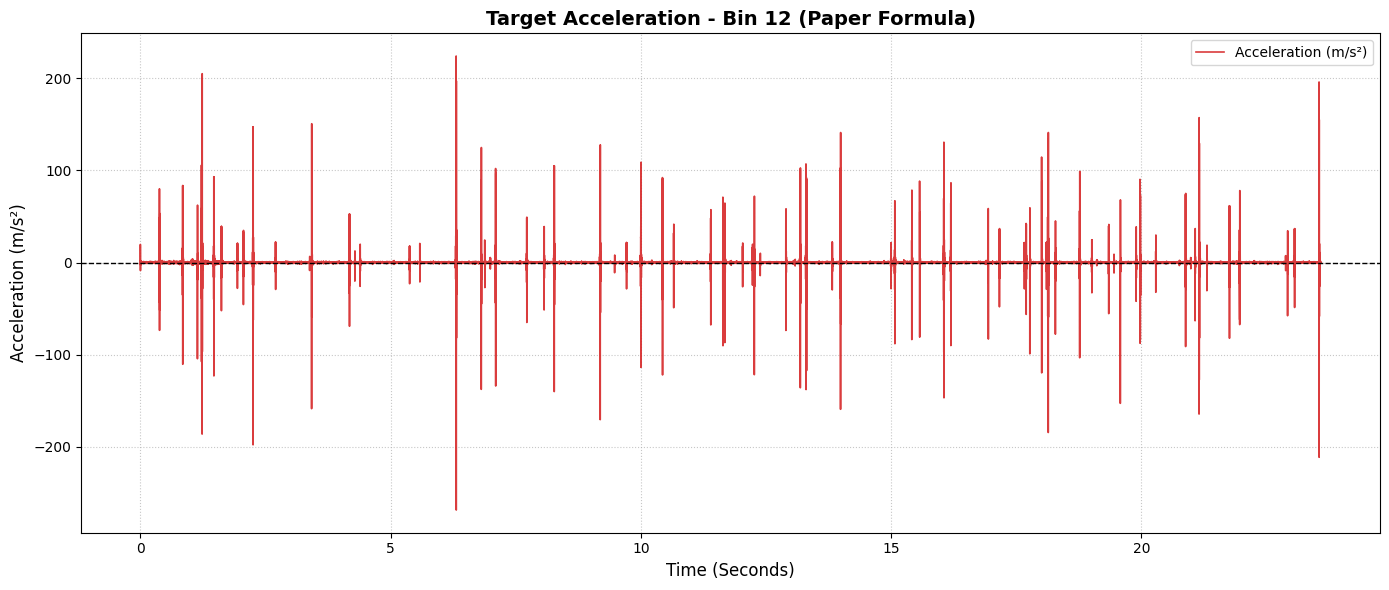

In [75]:
all_accelerations = []
loaded_adc_data = np.load(DATA_PATH)

print(f"Processing {num_frames} frames for Bin {target_bin}...")

for f in range(start_frame, start_frame + num_frames):
    raw_frame = loaded_adc_data[f-1 : f]
    acc_frame = process_one_frame(raw_frame, target_bin)
    all_accelerations.extend(acc_frame)

all_accelerations = np.array(all_accelerations)

plt.figure(figsize=(14, 6))
time_axis = np.arange(len(all_accelerations)) * Tloop

plt.plot(time_axis, all_accelerations, color='#d62728', linewidth=1.2, alpha=0.9, label='Acceleration (m/s²)')

plt.title(f"Target Acceleration - Bin {target_bin} (Paper Formula)", fontsize=14, fontweight='bold')
plt.xlabel("Time (Seconds)", fontsize=12)
plt.ylabel("Acceleration (m/s²)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()

target_folder="Accelerations"
os.makedirs(f"{save_dir}/{target_folder}", exist_ok=True)
plt.savefig(f"{save_dir}/Accelerations/Accel_Bin_{target_bin}.png")
plt.show()